In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install -q langchain
!pip install -q langchain-community
!pip install -q langchain-huggingface
!pip install -q sentence-transformers
!pip install -q faiss-cpu
!pip install -q pypdf
!pip install -q python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
moviepy 1.0.3 requ

In [29]:
!pip install -q langchain-text-splitters

In [31]:
!pip list | grep langchain

langchain                                1.2.15
langchain-classic                        1.0.8
langchain-community                      0.4.2
langchain-core                           1.5.3
langchain-huggingface                    1.2.2
langchain-protocol                       0.0.18
langchain-text-splitters                 1.1.2


In [49]:
!pip install -q langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.6 MB/s eta 0:00:00a 0:00:01


# Libraries

In [55]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

# Load Data

In [4]:
# Read dataset
data_path = "/kaggle/input/datasets/rahmaashrafabdullah/materials"

print("Materials:\n")
for file in os.listdir(data_path):
    print(file)

Materials:

Beginners_Guide_to_HTML.pdf
python_basics_sample_chapters.pdf
sql_basics.pdf


In [5]:
# Load PDF documents from the dataset
documents = []

for file in os.listdir(data_path):
    if file.endswith(".pdf"):
        file_path = os.path.join(data_path, file)
        loader = PyPDFLoader(file_path)
        documents.extend(loader.load())

In [6]:
print(f"Total Pages: {len(documents)}")

Total Pages: 236


# EDA

In [7]:
# Display the total number of PDF files and loaded pages
num_files = len(os.listdir(data_path))
num_pages = len(documents)

print(f"Number of PDF Files : {num_files}")
print(f"Total Loaded Pages  : {num_pages}")

Number of PDF Files : 3
Total Loaded Pages  : 236


In [8]:
print(documents[0])

page_content='' metadata={'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': '/kaggle/input/datasets/rahmaashrafabdullah/materials/Beginners_Guide_to_HTML.pdf', 'total_pages': 59, 'page': 0, 'page_label': '1'}


In [9]:
documents[0].metadata

{'producer': 'PyPDF',
 'creator': 'PyPDF',
 'creationdate': '',
 'source': '/kaggle/input/datasets/rahmaashrafabdullah/materials/Beginners_Guide_to_HTML.pdf',
 'total_pages': 59,
 'page': 0,
 'page_label': '1'}

In [10]:
# Show the content of the first loaded document page
print(documents[1].page_content[:1000])

Beginner’s Guide to HTML 
by Michael Gabriel  
1. GettingStarted: What YouNeedtoDotoGet GoingandMakeYourFirst HTML                               
Page 
1.1 What is HTML? 
1.2 Why learn HTML? 
1.3 What you need to know about HTML to get started 
2. Tags, Attributes and Elements  
2.1 What's the difference? 
2.2  HTML elements 
2.3 Tips 
2.4 Attributes 
3. Titles. Headings. Paragraphs.  
3.1 The title tag 
3.2 Headings 
3.3 Paragraphs 
4. Unnumbered, Numbered, Definition and Nested Lists 
4.1 Ordered lists 
4.2 Unordered lists 
4.3 Description lists 
4.4 Nested lists 
5.How to Makes Links to Other Pages and Elsewhere 
5.1 Regular or text links 
5.2 Image links 
5.3 Links to e­mail addresses 
5.4 Anchor links 
5.5 Other considerations when creating links 
6. How to Work with Images  
6.1 The alt attribute 
6.2 The width and height attributes 
6.3 Align your images 
6.4 Adding links to your images


In [11]:
# Calculate basic statistics for the lengths of document pages
page_lengths = [len(doc.page_content) for doc in documents]

print(f"Shortest Page: {min(page_lengths)}")
print(f"Longest Page: {max(page_lengths)}")
print(f"Average Length: {sum(page_lengths)/len(page_lengths):.2f}")

Shortest Page: 0
Longest Page: 1947
Average Length: 814.06


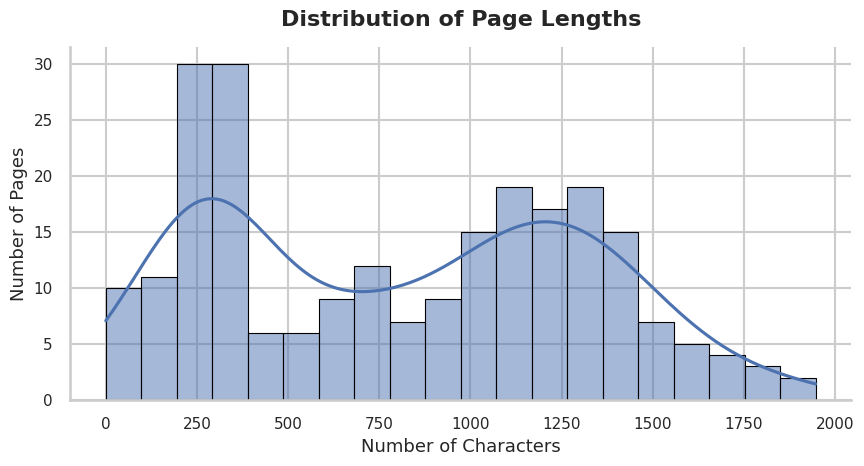

In [14]:
# Visualize the distribution of document page lengths
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(9, 5))

sns.histplot(page_lengths,bins=20,color="#4C72B0",edgecolor="black",linewidth=0.8,kde=True)

plt.title("Distribution of Page Lengths",fontsize=16,fontweight="bold",pad=15)
plt.xlabel("Number of Characters", fontsize=13)
plt.ylabel("Number of Pages", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

In [15]:
# Count the number of pages loaded from each PDF document
page_counts = {}

for doc in documents:
    file_name = os.path.basename(doc.metadata["source"])
    page_counts[file_name] = page_counts.get(file_name, 0) + 1

page_df = pd.DataFrame(
    page_counts.items(),
    columns=["Document", "Pages"]
)

page_df

,Document,Pages
0,Beginners_Guide_to_HTML.pdf,59
1,python_basics_sample_chapters.pdf,98
2,sql_basics.pdf,79


/tmp/ipykernel_58/3366120695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=page_df,x="Document",y="Pages",palette="Blues_d",edgecolor="black",linewidth=1)


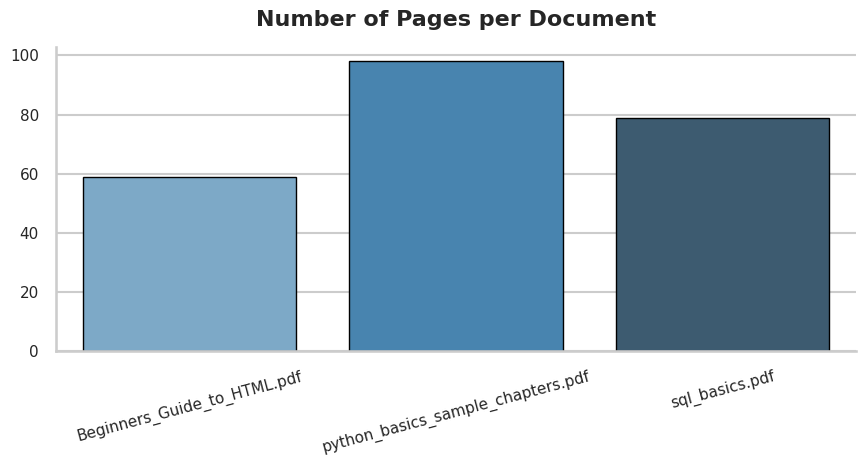

In [16]:
# Visualize the number of pages for each PDF document
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(9, 5))

sns.barplot(data=page_df,x="Document",y="Pages",palette="Blues_d",edgecolor="black",linewidth=1)

plt.title("Number of Pages per Document",fontsize=16,fontweight="bold",pad=15)
plt.xlabel("")
plt.ylabel("")

plt.xticks(rotation=15, fontsize=11)
plt.yticks(fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

In [17]:
# Summarize the text length of each loaded document page
text_lengths = [len(doc.page_content) for doc in documents]

length_df = pd.DataFrame(
    text_lengths,
    columns=["Characters"]
)
length_df.describe()

,Characters
count,236.000000
mean,814.055085
std,501.019889
min,0.000000
25%,309.500000
50%,822.500000
75%,1239.500000
max,1947.000000


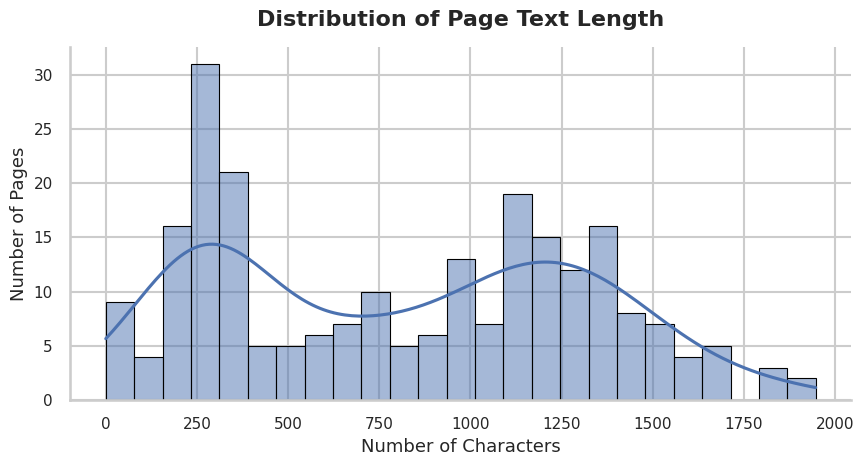

In [18]:
# Visualize the distribution of text lengths 
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(9, 5))

sns.histplot(text_lengths,bins=25,color="#4C72B0",edgecolor="black",linewidth=0.8,kde=True)

plt.title("Distribution of Page Text Length",fontsize=16,fontweight="bold",pad=15)

plt.xlabel("Number of Characters", fontsize=13)
plt.ylabel("Number of Pages", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

# Data Preprocessing

In [19]:
# Count the number of empty pages 
empty_pages = sum(
    1 for doc in documents
    if len(doc.page_content.strip()) == 0
)

print(f"Empty Pages: {empty_pages}")

Empty Pages: 2


In [20]:
# Remove Empty Pages
documents = [
    doc for doc in documents
    if doc.page_content.strip()
]

print(f"Pages After Removing Empty Pages: {len(documents)}")

Pages After Removing Empty Pages: 234


In [22]:
# Clean Text
for doc in documents:
    text = doc.page_content

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Remove multiple newlines
    text = re.sub(r"\n+", "\n", text)

    # Strip leading spaces
    text = text.strip()

    doc.page_content = text

In [23]:
print(documents[0].page_content[:1000])

Beginner’s Guide to HTML by Michael Gabriel 1. GettingStarted: What YouNeedtoDotoGet GoingandMakeYourFirst HTML Page 1.1 What is HTML? 1.2 Why learn HTML? 1.3 What you need to know about HTML to get started 2. Tags, Attributes and Elements 2.1 What's the difference? 2.2 HTML elements 2.3 Tips 2.4 Attributes 3. Titles. Headings. Paragraphs. 3.1 The title tag 3.2 Headings 3.3 Paragraphs 4. Unnumbered, Numbered, Definition and Nested Lists 4.1 Ordered lists 4.2 Unordered lists 4.3 Description lists 4.4 Nested lists 5.How to Makes Links to Other Pages and Elsewhere 5.1 Regular or text links 5.2 Image links 5.3 Links to e­mail addresses 5.4 Anchor links 5.5 Other considerations when creating links 6. How to Work with Images 6.1 The alt attribute 6.2 The width and height attributes 6.3 Align your images 6.4 Adding links to your images


In [25]:
# Check Page Lengths After Cleaning
page_lengths = [len(doc.page_content) for doc in documents]

print(f"Shortest Page: {min(page_lengths)}")
print(f"Longest Page: {max(page_lengths)}")
print(f"Average Length: {sum(page_lengths)/len(page_lengths):.2f}")

Shortest Page: 39
Longest Page: 1947
Average Length: 775.11


In [32]:
# Configure the text splitter for chunking documents
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

In [33]:
chunks = text_splitter.split_documents(documents)

print(f"Number of Chunks: {len(chunks)}")

Number of Chunks: 528


In [34]:
print(chunks[0].page_content)

Beginner’s Guide to HTML by Michael Gabriel 1. GettingStarted: What YouNeedtoDotoGet GoingandMakeYourFirst HTML Page 1.1 What is HTML? 1.2 Why learn HTML? 1.3 What you need to know about HTML to get started 2. Tags, Attributes and Elements 2.1 What's the difference? 2.2 HTML elements 2.3 Tips 2.4 Attributes 3. Titles. Headings. Paragraphs. 3.1 The title tag 3.2 Headings 3.3 Paragraphs 4. Unnumbered, Numbered, Definition and Nested Lists 4.1 Ordered lists 4.2 Unordered lists 4.3 Description lists


In [35]:
# Calculate basic statistics for the generated text chunks
chunk_lengths = [
    len(chunk.page_content)
    for chunk in chunks
]

print(f"Shortest Chunk: {min(chunk_lengths)}")
print(f"Longest Chunk: {max(chunk_lengths)}")
print(f"Average Length: {sum(chunk_lengths)/len(chunk_lengths):.2f}")

Shortest Chunk: 39
Longest Chunk: 500
Average Length: 394.41


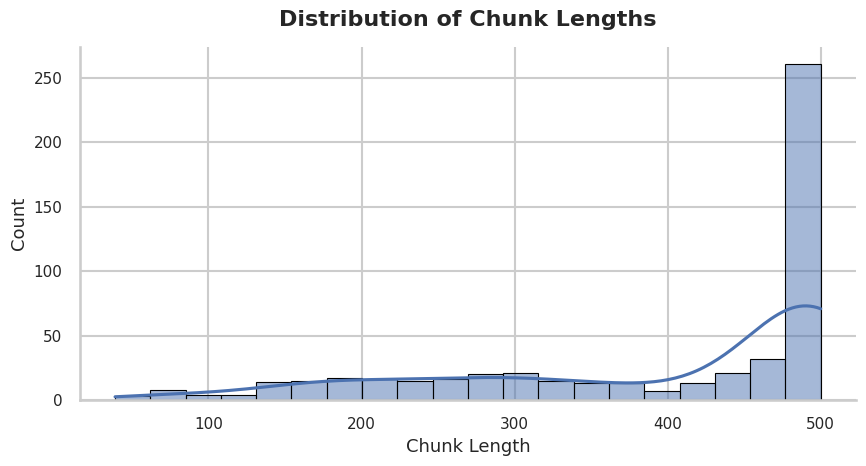

In [36]:
# Visualize the distribution of generated text chunk lengths
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(9, 5))

sns.histplot(chunk_lengths,bins=20,color="#4C72B0",edgecolor="black",linewidth=0.8,kde=True)

plt.title("Distribution of Chunk Lengths",fontsize=16,fontweight="bold",pad=15)
plt.xlabel("Chunk Length", fontsize=13)
plt.ylabel("Count", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

In [37]:
print(chunks[0].metadata)

{'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': '/kaggle/input/datasets/rahmaashrafabdullah/materials/Beginners_Guide_to_HTML.pdf', 'total_pages': 59, 'page': 1, 'page_label': '2'}


In [39]:
# Load Embedding model
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# Vector Database

In [41]:
# Create a FAISS vector database
vector_db = FAISS.from_documents(
    documents=chunks,
    embedding=embedding_model
)

In [43]:
# Save the vector database
vector_db.save_local("faiss_index")

print("FAISS index saved successfully.")

FAISS index saved successfully.


# Retriever

In [44]:
# Create Retriever
retriever = vector_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

In [45]:
# Test the Retriever
query = "What is Python?"

retrieved_docs = retriever.invoke(query)

In [46]:
for i, doc in enumerate(retrieved_docs, 1):
    print(f"\n========== Chunk {i} ==========\n")
    print(doc.page_content[:500])


========== Chunk 1 ==========

started on projects of your own. No matter what your ultimate goals may be, if you work with a com- puter at all, then you’ll soon be ﬁnding endless ways to improve your life by automating tasks and solving problems through Python pro- grams that you create. But what’s so great about Python as a programming language? For one, Python is open source freeware, meaning you can downloadit for free and use it for any purpose, commercial or not. Python also has an amazing community that has built a

========== Chunk 2 ==========

Foreword Hello, and welcome to Python Basics: A Practical Introduction to Python 3. I hope you’re ready to learn why so many professional and hobbyist developers are drawn to Python and how you can begin using it on your own projects, small and large, right away. This book is targeted at beginners who either know a little program- mingbutnotthePythonlanguageandecosystemorarestartingf resh with no programming experience whatsoever. Ifyo

# Initialize LLM

In [51]:
# Load LLM
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["GROQ_API_KEY"] = user_secrets.get_secret("GROQ_API_KEY")

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [53]:
# Define the output schema
class GradeDocuments(BaseModel):
    binary_score: str = Field(
        description="Return 'yes' if the retrieved documents are relevant to the question, otherwise return 'no'."
    )

In [54]:
structured_llm = llm.with_structured_output(GradeDocuments)

In [56]:
# Create prompt
grade_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a retrieval grader.

Your task is to determine whether the retrieved document contains information
that is relevant to the user's question.

If the document is relevant, return "yes".
If it is not relevant, return "no".

Do not explain your answer.
            """
        ),
        (
            "human",
            """
Retrieved document:

{document}

User question:

{question}
            """
        ),
    ]
)

In [58]:
# Evaluate whether the retrieved document is relevant to the user's query
retrieval_grader = grade_prompt | structured_llm

result = retrieval_grader.invoke(
    {
        "question": query,
        "document": retrieved_docs[0].page_content
    }
)

print(result)

binary_score='yes'


In [59]:
# Testing
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a query rewriter.

Rewrite the user's question to improve document retrieval.
Return only the rewritten question.
            """
        ),
        (
            "human",
            "{question}"
        ),
    ]
)

query_rewriter = rewrite_prompt | llm

def corrective_retrieval(question):
    retrieved_docs = retriever.invoke(question)

    relevant_docs = []

    # Evaluate all retrieved chunks
    for doc in retrieved_docs:

        grade = retrieval_grader.invoke(
            {
                "question": question,
                "document": doc.page_content
            }
        )

        if grade.binary_score.lower() == "yes":
            relevant_docs.append(doc)

    # If relevant chunks exist, return them
    if relevant_docs:
        return relevant_docs

    rewritten_question = query_rewriter.invoke(
        {"question": question}
    ).content

    print(f"Rewritten Query: {rewritten_question}")
    return retriever.invoke(rewritten_question)

In [60]:
# Generate final answer
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a helpful AI assistant.

Answer the user's question using ONLY the provided context.

Rules:
- Do not use outside knowledge.
- If the answer is not found in the context, reply:
"I could not find the answer in the provided documents."
- Keep your answer clear and concise.
            """
        ),
        (
            "human",
            """
Question:
{question}

Context:
{context}
            """
        ),
    ]
)

answer_chain = answer_prompt | llm

def generate_answer(question):

    docs = corrective_retrieval(question)

    context = "\n\n".join([doc.page_content for doc in docs])

    response = answer_chain.invoke(
        {
            "question": question,
            "context": context
        }
    )

    sources = list(set(doc.metadata["source"] for doc in docs))

    print("=" * 60)
    print("Answer:\n")
    print(response.content)

    print("\n" + "=" * 60)
    print("Sources:\n")

    for source in sources:
        print("-", source)

In [63]:
generate_answer("What is SQL?")

Answer:

Structured Query Language - SQL is a domain-specific language for relational databases only. It is declarative and set-at-a-time, meaning you describe what data you want and the system figures out how to execute it.

Sources:

- /kaggle/input/datasets/rahmaashrafabdullah/materials/sql_basics.pdf
